<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day10_practice1_%EC%B6%94%EB%A1%A0_%EC%98%B5%EC%85%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# YOLO 추론 옵션
# 학습(training): 모델에게 정답이 딸린 데이터를 잔뜩 보여주며 파라미터(가중치)를 조정하는 과정
# 추론(inference): 학습이 끝나 고정된 모델에 새로운 입력을 넣어 예측·판단을 뽑아내는 과정

In [4]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.4 MB/s eta 0:00:00


In [5]:
!apt-get -qq install -y fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# Install NanumGothic font
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv

fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 120 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (26.7 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tt

In [6]:
from ultralytics import YOLO
import urllib.request, os, time

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [7]:
# 감지 결과 이미지 출력 함수
def show(r, title=""):
  plt.figure(figsize=(5,6))
  plt.imshow(r.plot()[:,:,::-1]) # r.plot() = BGR → RGB로 뒤집게
  plt.axis("off")
  if title:
    plt.title(title)
  plt.show()

In [8]:
BUS_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"
if not os.path.exists("bus.jpg"):
  urllib.request.urlretrieve(BUS_URL, "bus.jpg")
  print("bus.jpg 다운로드 완료 (재실행 시 재사용)")

bus.jpg 다운로드 완료 (재실행 시 재사용)


yolo11n.pt: 파라미터 2.6M | 추론 8248ms | 감지 5개


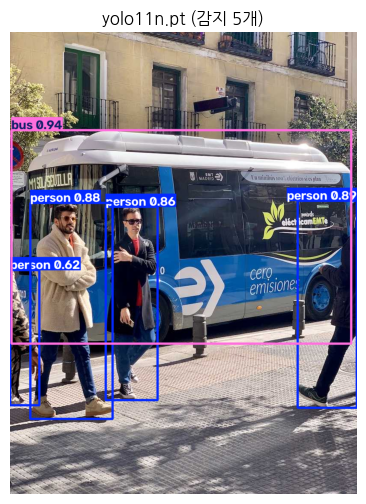

yolo11s.pt: 파라미터 9.5M | 추론 270ms | 감지 5개


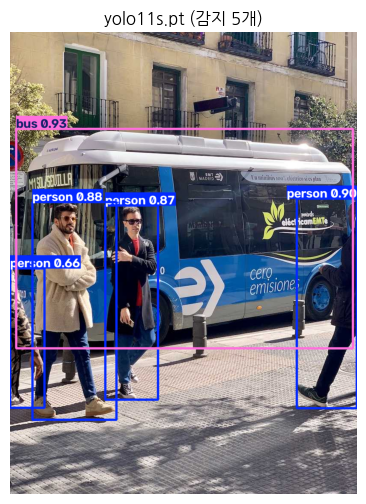

In [9]:
# 셀 1. 모델 크기 - n vs s 실측 비교
# yolo11n < s < m < l < x (커질수록 정확up↑ 속도down↓)
# nano: 파라미터 2.6M   모바일·실시간
# small: 파라미터 9.5M   서버에서 무난
# m/l/x - GPU 서버급

for name in ["yolo11n.pt", "yolo11s.pt"]: # nano, small
  model = YOLO(name)
  t0 = time.time()
  r = model("bus.jpg", verbose=False)[0]
  dt = (time.time() - t0) * 1000
  n_params = sum(p.numel() for p in model.model.parameters()) # 총 파라미터 수 : model.model.parameters()각 층의 가중치·편향이 텐서 형태로 나온다. .numel() 그 텐서 하나에 든 숫자(=파라미터)개수
  print(f"{name}: 파라미터 {n_params/1e6:.1f}M | 추론 {dt:.0f}ms | 감지 {len(r.boxes)}개")
  show(r, f"{name} (감지 {len(r.boxes)}개)")


[conf threshold]
conf=0.1  -> 6개 ['bus', 'person', 'person', 'person', 'person', 'skateboard']


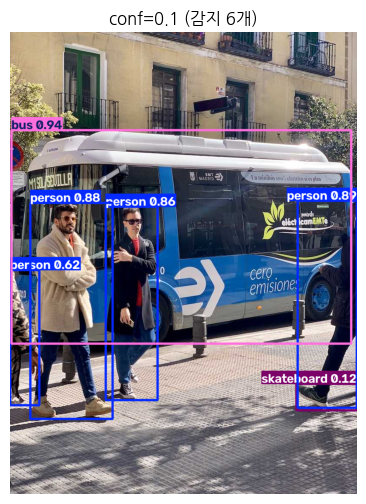

conf=0.25 -> 5개 ['bus', 'person', 'person', 'person', 'person']


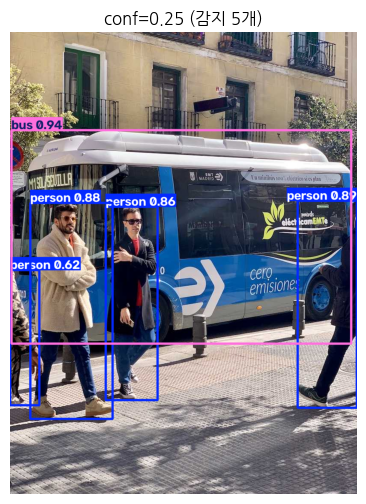

conf=0.5  -> 5개 ['bus', 'person', 'person', 'person', 'person']


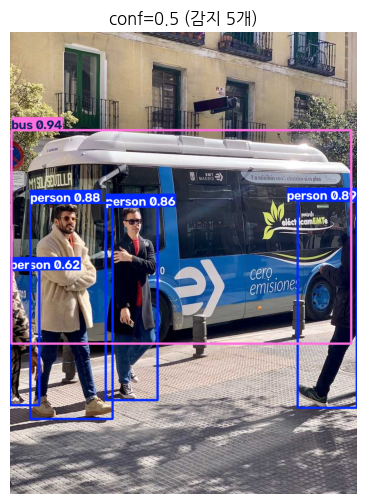

conf=0.8  -> 4개 ['bus', 'person', 'person', 'person']


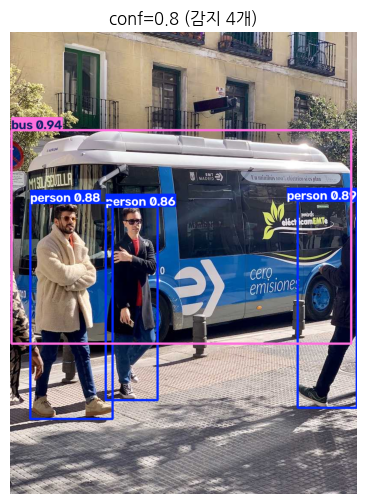

In [10]:
# 셀 2. conf - 신뢰도 threshold (기본 0.25)

model = YOLO("yolo11n.pt")
print("\n[conf threshold]")
for conf in [0.1, 0.25, 0.5, 0.8]:
  r = model("bus.jpg", conf=conf, verbose=False)[0] # conf=이 값 이상만 채택
  names = [r.names[int(b.cls)] for b in r.boxes]
  print(f"conf={conf:<4} -> {len(r.boxes)}개 {names}")
  show(r, f"conf={conf} (감지 {len(r.boxes)}개)")




[iou(NNS) threshold]
 iou=0.3  -> 5개


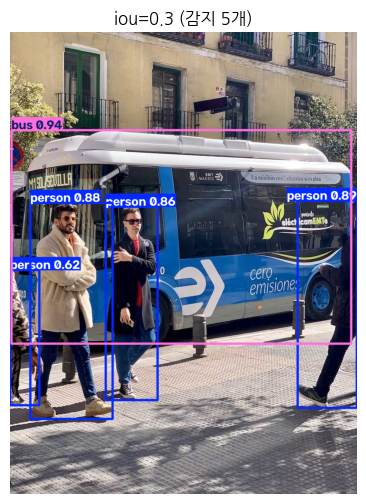

 iou=0.7  -> 5개


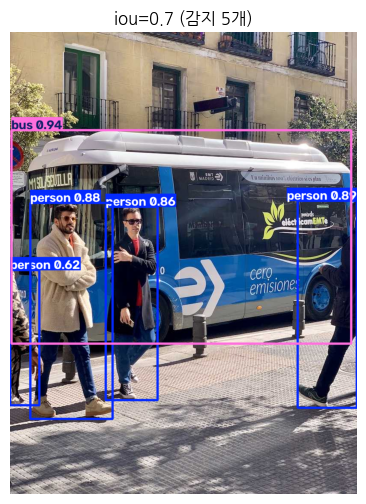

 iou=0.95 -> 8개


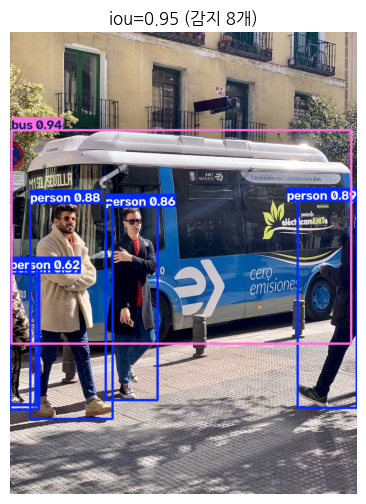

In [11]:
# 셀 3. IoU 0 NNS threshold (기본 0.7)
print("\n[iou(NNS) threshold]")
for iou_thr in [0.3,0.7,0.95]:
  r = model("bus.jpg", iou=iou_thr, verbose=False)[0]
  print(f" iou={iou_thr:<4} -> {len(r.boxes)}개")
  show(r, f"iou={iou_thr} (감지 {len(r.boxes)}개)")

  # NNS: 1등과 IoU가 이 값 이상이면 같은 문제로 보고 삭제
  # iou threshold 낮추면 -> 조금만 겹쳐도 삭제 -> 박스가 준다 (붙어 있는 물체를 하나로 합칠 위험)
  # iou threshold 높이면 -> 많이 겹쳐야 삭제 -> 박스가 는다 (한 물체에 중복 박스 위험)


[imgsz 입력 크기]
 imgsz=320   -> 감지 5 개 | 93ms


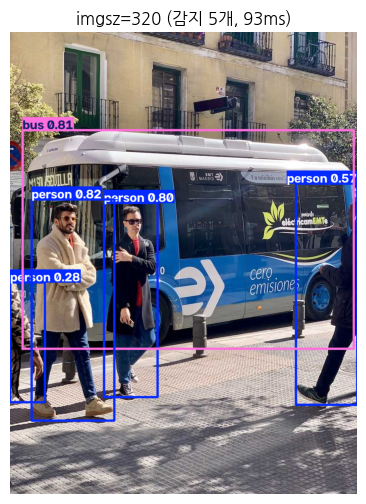

 imgsz=640   -> 감지 5 개 | 31ms


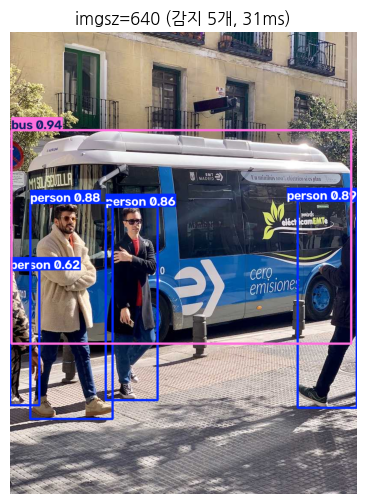

WARNING ⚠️ imgsz=[1200] must be multiple of max stride 32, updating to [1216]
 imgsz=1200  -> 감지 4 개 | 96ms


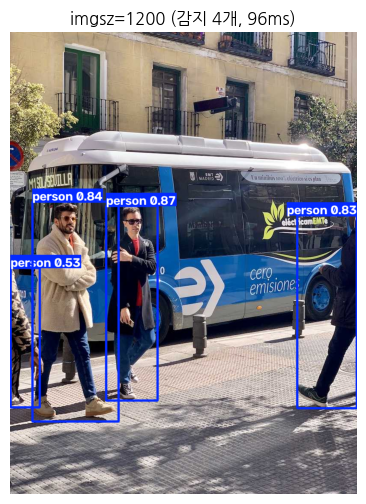

In [12]:
# 셀 4. imgsz - 입력 크기 (기본 640)
print("\n[imgsz 입력 크기]")
for size in [320, 640, 1200]: # 입력 리사이즈 크기 3개
  t0 = time.time()
  r = model("bus.jpg", imgsz=size, verbose=False)[0] # imgsz= 내부 리사이즈 픽셀
  dt = (time.time() - t0) * 1000
  print(f" imgsz={size:<5} -> 감지 {len(r.boxes)} 개 | {dt:.0f}ms")
  show(r, f"imgsz={size} (감지 {len(r.boxes)}개, {dt:.0f}ms)")

  #원거리에서 찍힌 포트홀처럼 수십 픽셀짜리 물체는 줄이면 뭉개져 사라진다. 이미지를 크게 해서 넣는다.ㅁ


[classes 필터]
 classes=[0](person만) -> 4개


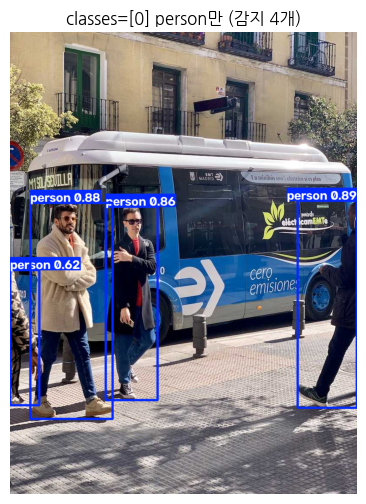

 classes=[5](bus만) -> 1개


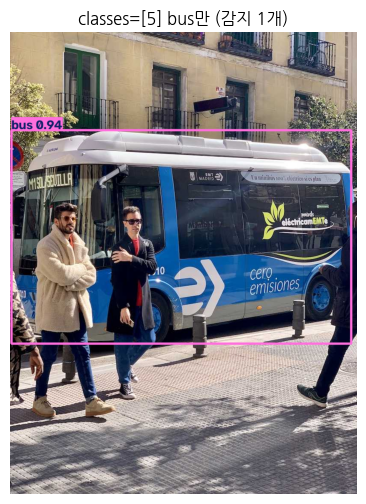


COCO 클래스는 총 80총: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck'] ...


In [13]:
# 셀 5. classes - 원하는 클래스만 알림
print("\n[classes 필터]")

r = model("bus.jpg", classes=[0], verbose=False)[0] # 사람만
print(f" classes=[0](person만) -> {len(r.boxes)}개")
show(r, f"classes=[0] person만 (감지 {len(r.boxes)}개)")

r = model("bus.jpg", classes=[5], verbose=False)[0]
print(f" classes=[5](bus만) -> {len(r.boxes)}개")
show(r, f"classes=[5] bus만 (감지 {len(r.boxes)}개)")

print(f"\nCOCO 클래스는 총 {len(model.names)}총:", list(model.names.values())[:8], "...")

# 추론 옵션 5개 (모델크기/conf/IoU/imgsz/classes)